Import relevant libraries and import the file using a relative path.
Then Split the data into test and training. We use a specific seed as our random state so that we get the same result every time.

## Imports
- **pandas** is a library for data manipulation. We will use the pandas dataframe as it can easily be turned into PyTorch
- **pathlib** a smart little library used to make relative paths. This way we can have a path that is the same for everyone.
- **torch** The Pytorch library.
- **tranformers** we import AutoConfig and AutoModel from the HugginFace tranformer module. These are used to get the configuration from one of HugginFaces models, and then we create a model from that config using the AutoModel function.
- **train_test_split** this is used to split data into training and testing.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn #neural network module
import torch.nn.functional as F #functional module contains functions that don't have parameters, like activation functions and loss functions
from transformers import AutoConfig, AutoModel # AutoConfig is used to load the configuration of a pre-trained model, and AutoModel is used to load the pre-trained model itself.
from sklearn.model_selection import train_test_split #train_test_split is a function from scikit-learn that splits arrays or matrices into random train and test subsets.
from torch.utils.data import Dataset, DataLoader #Dataset is an abstract class representing a dataset, and DataLoader is a utility that provides an iterable over the given dataset.

/home/jaspers/GitHub/MainRepo/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prepare Data
Import the dataset using the path variable. Then use the train_test_split() funtion to split the data into random train and test subsets.

bla bla bla... more text is coming.

In [16]:
df = pd.read_csv('datasets/LEAD/train_features.csv')
df_filtered = df[df['building_id'] == 1]
plt.figure(figsize=(15, 5))


# Split the data into features and target variable
#drop the 'anomaly' column and the 'timestamp' column from the training data to get the features
# We might or might not need the timestamp column, but for now we will drop it to simplify the data
X = df_filtered.drop(columns=['building_id', 'timestamp', 'anomaly', 'site_id'])
y = df_filtered['anomaly']

# try to convert everything
X = X.apply(pd.to_numeric, errors='coerce')

# then optionally drop columns that are still problematic (all NaN)
X = X.dropna(axis=1, how='all')

# fill remaining NaNs
X = X.fillna(0)
#shuffle=False to maintain the temporal order of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

IN_CHANNELS = X.shape[1] 
print(f'Number of features: {IN_CHANNELS}')
NUM_CLASSES = 2 # Binary Classification (anomaly or not)

# Create a custom dataset class for time series data
# This class will take in the features and target variable,
# and will return a window of consecutive rows as input and the corresponding label as output.
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        # Convert pandas data into PyTorch tensors
        self.X = torch.tensor(X.values, dtype=torch.float)
        self.y = torch.tensor(y.values, dtype=torch.float)

        # Save the number of timesteps per window
        self.window_size = window_size

    def __len__(self):
        # Number of possible sliding windows
        return len(self.X) - self.window_size + 1

    def __getitem__(self, idx):
        # Take consecutive rows from idx up to idx + window_size
        window = self.X[idx : idx + self.window_size]

        # Use the label of the last row in the window
        # Might be better to label according to wether any of the rows in the window are an attack
        label = self.y[idx + self.window_size - 1]

        return window, label

# create the training and testing datasets using with a window size of 32
train_dataset = TimeSeriesDataset(X_train, y_train, window_size=4)
test_dataset = TimeSeriesDataset(X_test, y_test, window_size=4)

# Create data loaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



Number of features: 46


<Figure size 1500x500 with 0 Axes>

Code for joining datasets and sorting

In [5]:
df = pd.read_csv("datasets/LEAD/train.csv", parse_dates=["timestamp"])
df_filtered = df[df["building_id"] == 1].copy()

features = pd.read_csv("datasets/LEAD/train_features.csv", parse_dates=["timestamp"])
features_filtered = features[features["building_id"] == 1].copy()

df_merged = df_filtered.merge(
    features_filtered,
    on=["building_id", "timestamp"],
    how="left"
)

X = df_merged.drop(columns=["anomaly", "building_id", "timestamp"])
y = df_merged["anomaly"]



# Get the unique primary_use categories from both train and test dataframes
all_categories = pd.concat([
    train_merged["primary_use"],
    test_merged["primary_use"]
]).unique()

# Create a mapping from primary_use categories to integer labels
primary_use_map = {}
for idx, category in enumerate(all_categories):
    primary_use_map[category] = idx

# Apply the mapping to the primary_use column in both train and test dataframes
train_merged["primary_use"] = train_merged["primary_use"].map(primary_use_map)
test_merged["primary_use"] = test_merged["primary_use"].map(primary_use_map)

# Group by building_id, sort by timestamp
train_merged = train_merged.sort_values(by=["building_id", "timestamp"])
test_merged = test_merged.sort_values(by=["building_id", "timestamp"])

KeyError: "['anomaly'] not found in axis"

Alternative way to load .mat file using scipy.io.loadmat

In [ ]:

from scipy.io import loadmat
import numpy as np

attack_data = loadmat('datasets/False-Data-Injection-Attack-Dataset/118-bus/CAISO_attack_data_118.mat')
normal_data = loadmat('datasets/False-Data-Injection-Attack-Dataset/118-bus/CAISO_normal_operation_data_118.mat') 

attack_df = pd.DataFrame(attack_data['total_attack'])
normal_df = pd.DataFrame(normal_data['outputvoltage'])

N = normal_data["outputvoltage"]

X_normal = np.vstack([
    np.concatenate([N[i,0].reshape(-1), N[i,1].reshape(-1)])
    for i in range(N.shape[0])
])

print(X_normal.shape)   # should be (420476, 236)

A = attack_data["total_attack"]

X_attack = np.vstack([
    np.hstack([A[i,1], A[i,2]])   # (3,118) + (3,118) -> (3,236)
    for i in range(A.shape[0])
])

print(X_attack.shape)   # should be (30000, 236)

(420476, 236)
(30000, 236)


# Plotting features

This is how to plot features using matplotlib.
Might become valuable if we want to analyse specific features later.

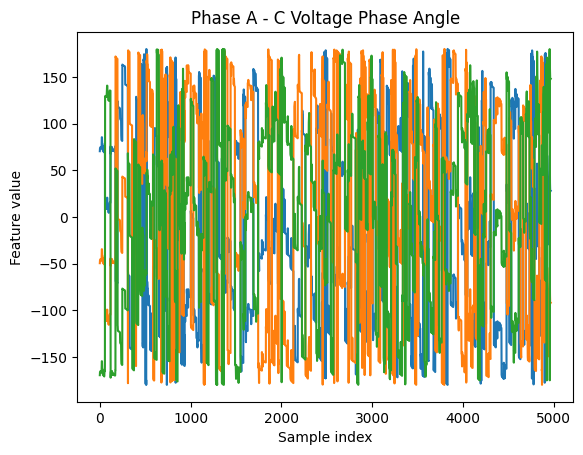

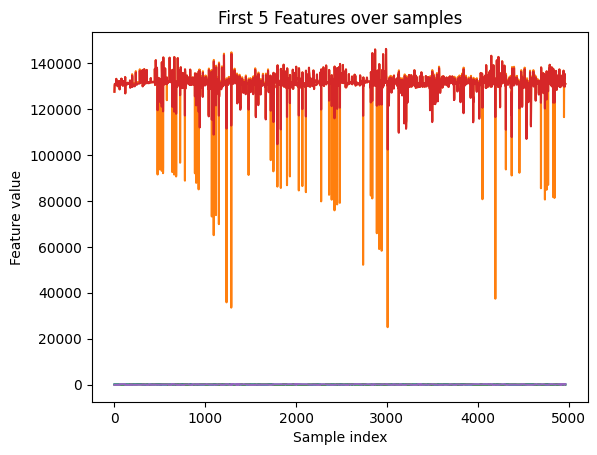

In [ ]:
#Hvordan man plotter en feature? (Måske er det nydvendigt senere)
df_numeric = df.apply(pd.to_numeric, errors="coerce")

# Plot Specific features using regex to filter columns that match the pattern 'R1-PA[1-3]:VH'
plt.plot(df_numeric.filter(regex=r'^R1-PA[1-3]:VH$'))
plt.xlabel("Sample index")
plt.ylabel("Feature value")
plt.title("Phase A - C Voltage Phase Angle")
plt.show()

# Plot the first 5 features as an example
plt.plot(df_numeric.iloc[:, 0:5])
plt.xlabel("Sample index")
plt.ylabel("Feature value")
plt.title("First 5 Features over samples")
plt.show()


# CNN Feature Extractor

- self.cnn = nn.Sequential()
    - order of inputs define which order each layer should execute in

- nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1)
    - in_channels : Number of input features, so how many variables are in each timestep
    - 32 : Output channels. How many patterns the CNN will learn.
    - Kernel_size : Size of the filter
    - Stride : how many steps we move the filter
    - padding : how many 0 we add to the start and end of the input. Prevents the sequence from shrinking too much. 

- nn.BatchNorm1d(32)
    - Normalizes the activations 
    
- nn.ReLU(inplace=True)
    - Means we are using relu
    - Inplace : modifys the current tensor directly, instead of creating a whole new tensor. This saves memory. 

- nn.MaxPool1d(2)
    - Reduce the sequence lenght by only keeping only the strongest activations
    - the 2, means that the seqence lenght is halved

In [6]:
class FeatureExtractor(nn.Module):
    def __init__(self, in_channels, d_model):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # reduce the sequence length by half

            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2), 

            nn.Conv1d(128, d_model, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU()
        )
        
    def forward(self, x):
        return self.features(x)

# Classifier
This module implements the final classification head of the model. Its purpose is to thransform the feature representation produced by the FeatureExtractor into class logits.

The classifier takes a feature vectore and predicts the probability of each class.

- Flatten
    - Converts the input tensor into a 1-dimentional feature vector
- Linear Layer
    - Fully connected layer that learns combinations of the extracted features.
    - Reduces the feature dimension
- ReLU
    - Applies the non-linear function `f(x) = max(0, x)`
- Dropout
    - Randomly disables 20% of neurons during training.
    - Helps prevent overfitting by making the model rely on multiple features instead of a few dominant ones
- Linear Layer
    - Produces the final logits for each class.
    - For binary classification (`num_classes = 2`), the output shape becomes: `(batch_size, 2)`

In [7]:
class Classifier(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # single output for binary classification
        )

    def forward(self, x):
        return self.classifier(x)

# CNNTRansformer

- num_classes : Number of classes we want to classify prediction in. In our case it is binary (True / False)

- in_channels : Number of columns in dataset, or number of culumns the model should analyze. In our case it is all columns, expect for timestep. According to chat, we don't need timestep to make preidiction. 

- embed_dim : size of feature vector used by transformer. if training is unstable, reduce to 64, if model overfits, use 256. Embed_dim must be divisable by num_heads (FInd ud af specifikt h)

- num_heads : Number of attention heads in transformers mult-head attention layer. 

- num_layers : Number of transformer layers (?)

- mlp_dim : Size of feedforward inside each transformor layer (Hvorfor er det 256)

- dropout : Percentage of neurons we randomly turn off during each training step. 

In [8]:
class CNNTransformer(nn.Module):
    def __init__(self, in_channels, d_model, nhead, num_layers):
        super().__init__()
        
        self.feature_extractor = FeatureExtractor(in_channels, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.classifier = Classifier(d_model)

    def forward(self, x):
        # x: (batch_size, seq_len, in_channels)
        x = x.permute(0, 2, 1)                    # (batch_size, in_channels, seq_len)

        features = self.feature_extractor(x)      # (batch_size, d_model, seq_len//4)
        features = features.permute(0, 2, 1)      # (batch_size, seq_len//4, d_model)

        transformer_out = self.transformer_encoder(features)   # (batch_size, seq_len//4, d_model)

        out = transformer_out[:, -1, :]           # (batch_size, d_model)
        out = self.classifier(out)                # (batch_size, 1)

        return out.squeeze(-1)

# Train function

In [9]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

    return history

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for windows, labels in dataloader:
        windows = windows.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        logits = model(windows)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = windows.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct = 0

    with torch.no_grad():
        for windows, labels in dataloader:
            windows = windows.to(device)
            labels = labels.to(device).float()

            logits = model(windows)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            batch_size = windows.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            correct += (preds == labels).sum().item()

    return total_loss / total_samples, correct / total_samples

In [17]:
model = CNNTransformer(in_channels=IN_CHANNELS, d_model=256, nhead=8, num_layers=4)
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=nn.BCEWithLogitsLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-4),
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    num_epochs=10
)
print(history)

Epoch 1/10 | Train Loss: 0.0445 | Test Loss: 0.0811 | Test Acc: 0.9857
Epoch 2/10 | Train Loss: 0.0282 | Test Loss: 0.0860 | Test Acc: 0.9857
Epoch 3/10 | Train Loss: 0.0282 | Test Loss: 0.0869 | Test Acc: 0.9857
Epoch 4/10 | Train Loss: 0.0275 | Test Loss: 0.0838 | Test Acc: 0.9857
Epoch 5/10 | Train Loss: 0.0285 | Test Loss: 0.0817 | Test Acc: 0.9857
Epoch 6/10 | Train Loss: 0.0278 | Test Loss: 0.0856 | Test Acc: 0.9857
Epoch 7/10 | Train Loss: 0.0282 | Test Loss: 0.0818 | Test Acc: 0.9857
Epoch 8/10 | Train Loss: 0.0278 | Test Loss: 0.0804 | Test Acc: 0.9857
Epoch 9/10 | Train Loss: 0.0280 | Test Loss: 0.0818 | Test Acc: 0.9857
Epoch 10/10 | Train Loss: 0.0281 | Test Loss: 0.0802 | Test Acc: 0.9857
{'train_loss': [0.0445353133542408, 0.02818419745325584, 0.028152318981079415, 0.02753905391910353, 0.028492696531295165, 0.027839971225759638, 0.028225474212327146, 0.027832122846317725, 0.02801858309703054, 0.028057379202582028], 'test_loss': [0.08111633542030965, 0.08598010896114651, 0

# Transformer configuration 
- Config : Gets the  configuration of the pretrained model, in our case bert, which is from huggingface
- Model : generates the model from the configuration, initialized with randomized weights

The config, defines the following:
- hidden size : size of the vector used to represent each token inside the model. So the size of how many numbers should represent a token/word, and that becomes a vector. Must be divisible by number of heads. 

- number of layers : Number of transformer blocks stacked on top of eachother. Contains mult head layer connections. 12 layers. 

- number of attention heads : The amount of attention heads running in parralel. So each head would focus on different attention pattern (Long term relation, grammar, closely-related, etc.)

- intermediate size : hidden size of the feedforward network inside each tranformer network. Each layer has a small neural network. 
    - linear layer -> Activation function -> Linear layer
    - Often size = 4 * hidden size?

- dropout values : Regularization technique. Randomly turns of a percentage of random neurons. 

- vocabulary size : How many unqiue tokens a language knows. 

- positional embedding length : Defines maximum sequence length. So a model can only process at most x amount of tokens at once. Each position has a vector. For time series models this corresponds to max window size (sequence length).
    - final embedding = token embedding + positional embedding.


